# ORAS — Module 4: Surgical Tool Detection (YOLOv8)

Training a fine-tuned YOLOv8 model to detect 7 laparoscopic instruments (grasper, bipolar, hook, scissors, clipper, irrigator, specimen bag) using the Cholec80-Boxes dataset.

Each cell below is self-contained and shows its output visually before moving to the next step.

## Cell 1: Environment Setup and Data Verification

In [5]:
import torch
from pathlib import Path
import yaml
from ultralytics import YOLO
import matplotlib.pyplot as plt
from collections import Counter
import cv2
import random
import numpy as np
from pathlib import Path

# --- GPU check ---
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("VRAM:", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), "GB")
else:
    print("WARNING: No GPU detected — training will fall back to CPU and be very slow.")

# --- Dataset path verification ---
DATASET_DIR = Path(r"D:\Projects\oras\ml\datasets\cholec80_boxes_yolo")
DATA_YAML = DATASET_DIR / "data.yaml"

assert DATA_YAML.exists(), f"data.yaml not found at {DATA_YAML}"

with open(DATA_YAML) as f:
    data_config = yaml.safe_load(f)

print("\n--- data.yaml contents ---")
print(data_config)

# --- Count files in each split ---
for split in ("train", "val"):
    img_count = len(list((DATASET_DIR / "images" / split).glob("*.png")))
    lbl_count = len(list((DATASET_DIR / "labels" / split).glob("*.txt")))
    print(f"\n{split}: {img_count} images, {lbl_count} label files")
    assert img_count == lbl_count, f"Mismatch in {split}: images and labels don't line up 1:1"

print("\nAll checks passed — dataset is ready for training.")

PyTorch version: 2.12.1+cu126
CUDA available: True
GPU: NVIDIA GeForce RTX 2060
VRAM: 6.4 GB

--- data.yaml contents ---
{'path': 'D:/Projects/oras/ml/datasets/cholec80_boxes_yolo', 'train': 'images/train', 'val': 'images/val', 'names': {0: 'Grasper', 1: 'Bipolar', 2: 'Hook', 3: 'Scissors', 4: 'Clipper', 5: 'Irrigator', 6: 'SpecimenBag'}}

train: 11238 images, 11238 label files

val: 2957 images, 2957 label files

All checks passed — dataset is ready for training.


## Cell 2: Class Distribution Analysis

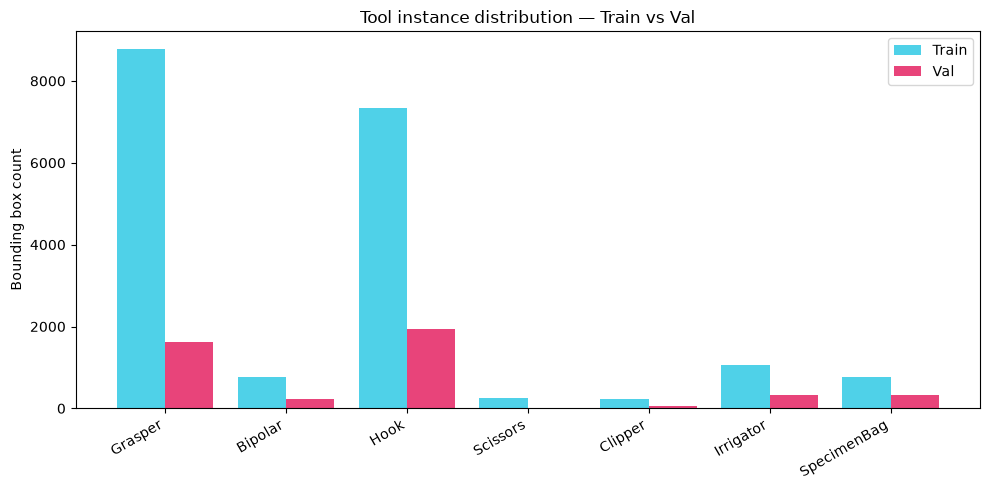

Train instance counts: {'Grasper': 8773, 'Hook': 7347, 'Bipolar': 760, 'Irrigator': 1068, 'Clipper': 232, 'Scissors': 263, 'SpecimenBag': 775}
Val instance counts:   {'Grasper': 1626, 'Hook': 1931, 'Clipper': 53, 'Scissors': 14, 'SpecimenBag': 316, 'Irrigator': 328, 'Bipolar': 222}


In [2]:
import matplotlib.pyplot as plt
from collections import Counter

CLASS_NAMES = data_config["names"]  # dict: {0: 'Grasper', 1: 'Bipolar', ...}

def count_instances(split):
    counts = Counter()
    label_files = (DATASET_DIR / "labels" / split).glob("*.txt")
    for lf in label_files:
        for line in lf.read_text().strip().splitlines():
            if not line.strip():
                continue
            class_id = int(line.split()[0])
            counts[CLASS_NAMES[class_id]] += 1
    return counts

train_counts = count_instances("train")
val_counts = count_instances("val")

all_classes = list(CLASS_NAMES.values())
train_vals = [train_counts.get(c, 0) for c in all_classes]
val_vals = [val_counts.get(c, 0) for c in all_classes]

x = range(len(all_classes))
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar([i - 0.2 for i in x], train_vals, width=0.4, label="Train", color="#4FD1E8")
ax.bar([i + 0.2 for i in x], val_vals, width=0.4, label="Val", color="#E8447A")
ax.set_xticks(list(x))
ax.set_xticklabels(all_classes, rotation=30, ha="right")
ax.set_ylabel("Bounding box count")
ax.set_title("Tool instance distribution — Train vs Val")
ax.legend()
plt.tight_layout()
plt.show()

print("Train instance counts:", dict(train_counts))
print("Val instance counts:  ", dict(val_counts))

## Cell 3: Visualize Sample Images with Ground-Truth Boxes

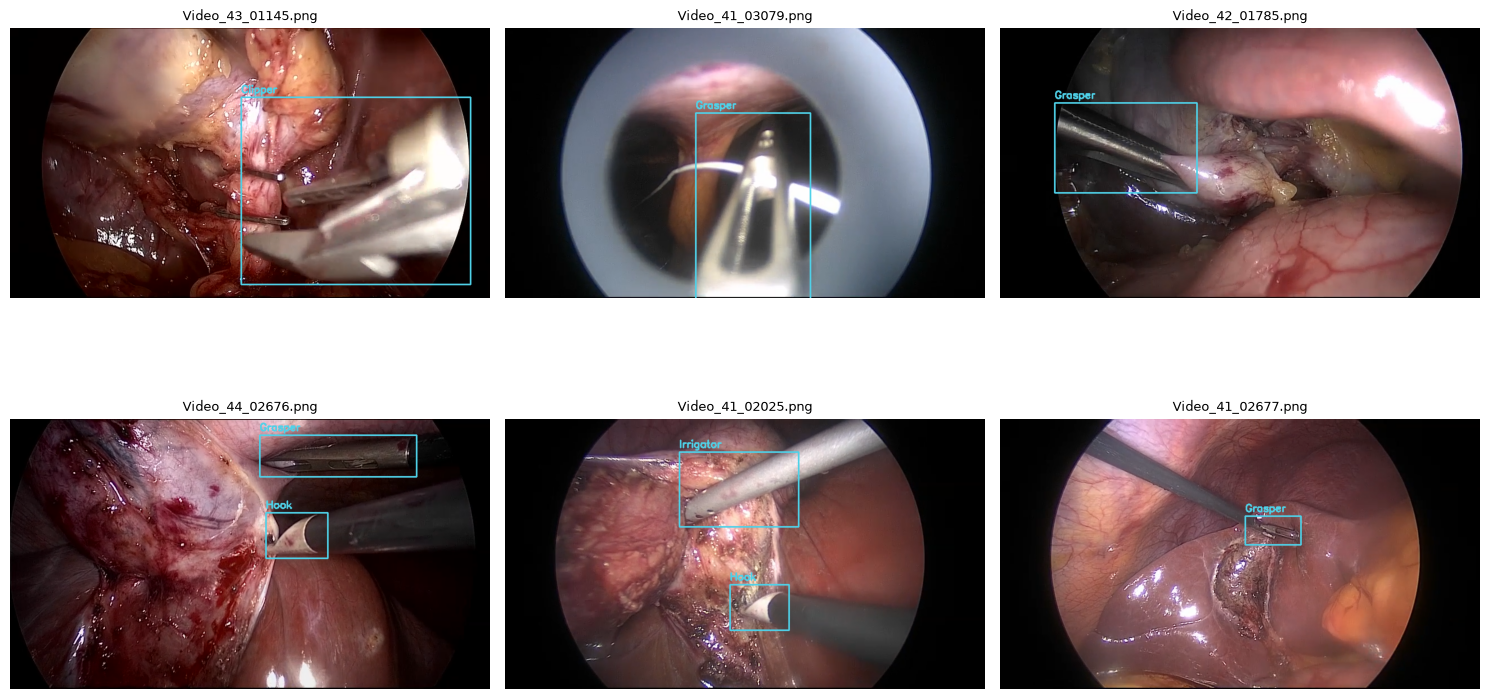

If boxes look correctly placed around tools above, the dataset is verified.
Re-run this cell a few times to spot-check different random samples.


In [3]:
import cv2
import random
import numpy as np

def draw_boxes_on_image(image_path, label_path, class_names):
    img = cv2.imread(str(image_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    lines = label_path.read_text().strip().splitlines()
    for line in lines:
        if not line.strip():
            continue
        class_id, cx, cy, bw, bh = line.split()
        class_id = int(class_id)
        cx, cy, bw, bh = float(cx), float(cy), float(bw), float(bh)

        box_w, box_h = bw * w, bh * h
        x1 = int((cx * w) - box_w / 2)
        y1 = int((cy * h) - box_h / 2)
        x2 = int((cx * w) + box_w / 2)
        y2 = int((cy * h) + box_h / 2)

        cv2.rectangle(img, (x1, y1), (x2, y2), (79, 209, 232), 2)
        label_text = class_names[class_id]
        cv2.putText(img, label_text, (x1, max(y1 - 8, 12)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (79, 209, 232), 2)
    return img

# Pick 6 random training images to spot-check
train_images = list((DATASET_DIR / "images" / "train").glob("*.png"))
sample_images = random.sample(train_images, 6)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, img_path in zip(axes.flat, sample_images):
    label_path = DATASET_DIR / "labels" / "train" / (img_path.stem + ".txt")
    img = draw_boxes_on_image(img_path, label_path, CLASS_NAMES)
    ax.imshow(img)
    ax.set_title(img_path.name, fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

print("If boxes look correctly placed around tools above, the dataset is verified.")
print("Re-run this cell a few times to spot-check different random samples.")

## Cell 4: YOLOv8 Training Configuration and Run

In [4]:
from pathlib import Path

# yolov8n = "nano" — smallest YOLOv8 variant, chosen deliberately to fit
# comfortably in 6GB VRAM. Larger variants (s/m/l) risk out-of-memory
# errors on the RTX 2060 at this image size and batch size.
model = YOLO("yolov8n.pt")  # auto-downloads pretrained COCO weights on first run

RUNS_DIR = Path(r"D:\Projects\oras\ml\runs")

results = model.train(
    data=str(DATA_YAML),
    epochs=30,          # first pass — extend later once this completes cleanly
    imgsz=640,
    batch=16,            # drop to 8 if you hit a CUDA out-of-memory error
    device=0,             # GPU 0 = your RTX 2060
    patience=10,         # stop early if no improvement for 10 epochs
    project=str(RUNS_DIR / "detect"),
    name="tool_detection_v1",
    workers=4,
)

print("\nTraining complete.")
print("Best weights saved at:", results.save_dir / "weights" / "best.pt")

New https://pypi.org/project/ultralytics/8.4.83 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.75  Python-3.12.9 torch-2.12.1+cu126 CUDA:0 (NVIDIA GeForce RTX 2060, 6144MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=D:\Projects\oras\ml\datasets\cholec80_boxes_yolo\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937

SystemError: Caught SystemError in DataLoader worker process 3.
Original numpy._core._exceptions._ArrayMemoryError: Unable to allocate 1.17 MiB for an array with shape (640, 640, 3) and data type uint8

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "d:\Projects\oras\ml\venv\Lib\site-packages\torch\utils\data\_utils\worker.py", line 374, in _worker_loop
    data = fetcher.fetch(index)  # type: ignore[possibly-undefined]
           ^^^^^^^^^^^^^^^^^^^^
  File "d:\Projects\oras\ml\venv\Lib\site-packages\torch\utils\data\_utils\fetch.py", line 54, in fetch
    data = [self.dataset[idx] for idx in possibly_batched_index]
            ~~~~~~~~~~~~^^^^^
  File "d:\Projects\oras\ml\venv\Lib\site-packages\ultralytics\data\base.py", line 397, in __getitem__
    return self.transforms(self.get_image_and_label(index))
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\Projects\oras\ml\venv\Lib\site-packages\ultral

In [2]:
print("Hello, world!")

Hello, world!


## Cell 4b: Resume Training From Last Checkpoint

In [3]:
# Resuming reads the original training config automatically from
# args.yaml in this run folder — same epochs target (30), same
# optimizer state, same learning-rate schedule, continuing from
# wherever it stopped (epoch 15).
resume_model = YOLO(r"D:\Projects\oras\ml\runs\detect\tool_detection_v1\weights\last.pt")
results = resume_model.train(resume=True)

print("\nTraining complete.")
print("Best weights saved at:", results.save_dir / "weights" / "best.pt")

New https://pypi.org/project/ultralytics/8.4.84 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.75  Python-3.12.9 torch-2.12.1+cu126 CUDA:0 (NVIDIA GeForce RTX 2060, 6144MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=D:\Projects\oras\ml\datasets\cholec80_boxes_yolo\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=D:\Projects\oras\ml\runs\d

## Cell 5: Training Results Visualization and Model Export

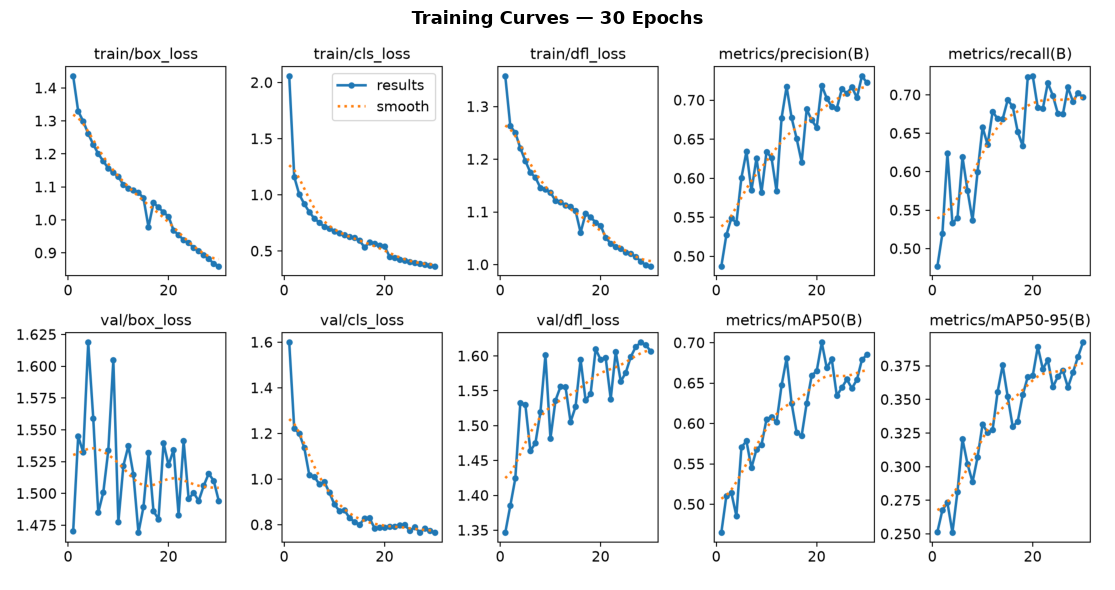

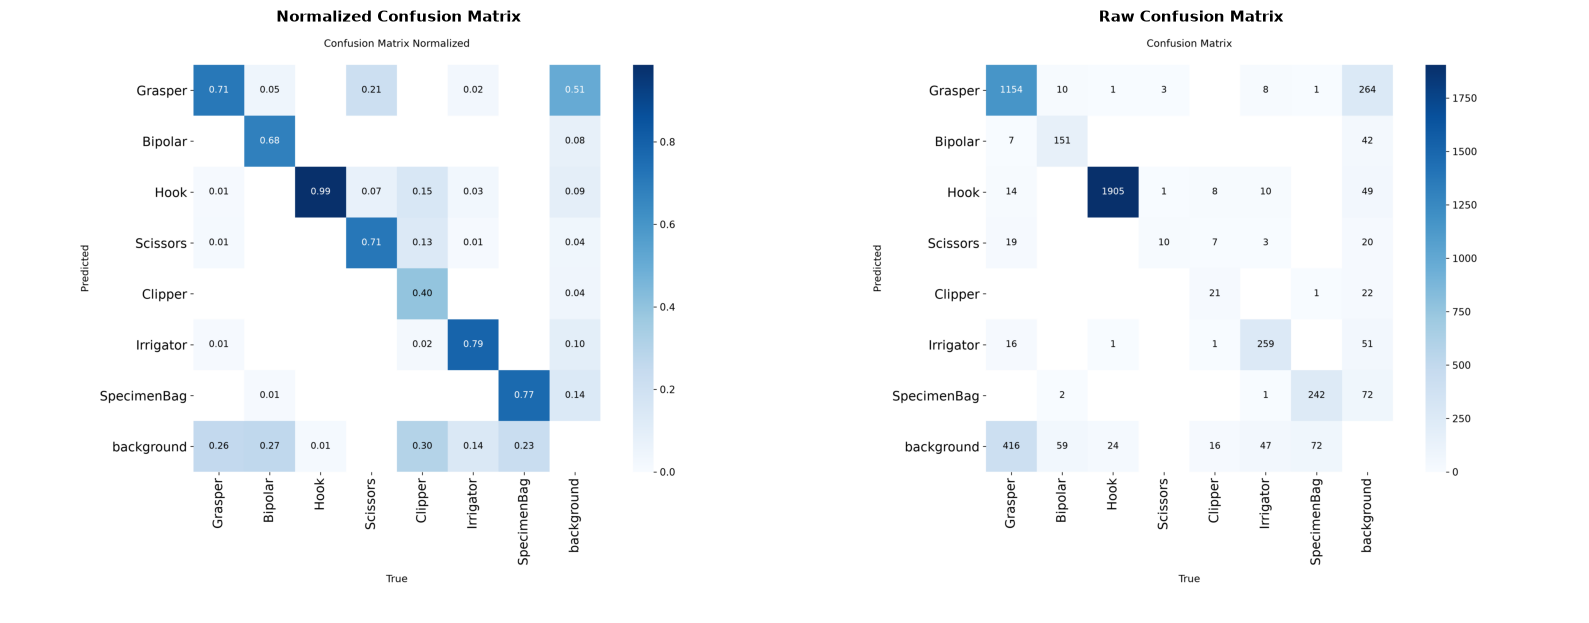

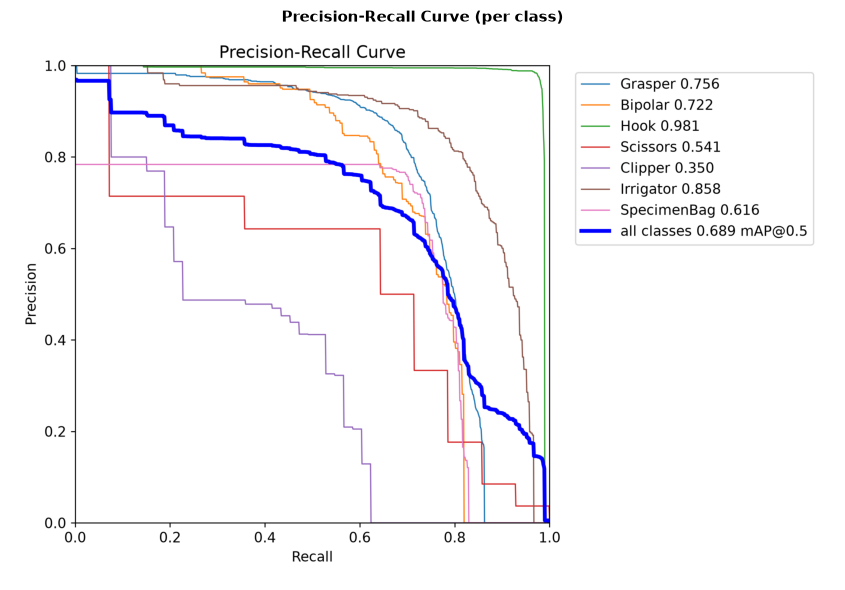

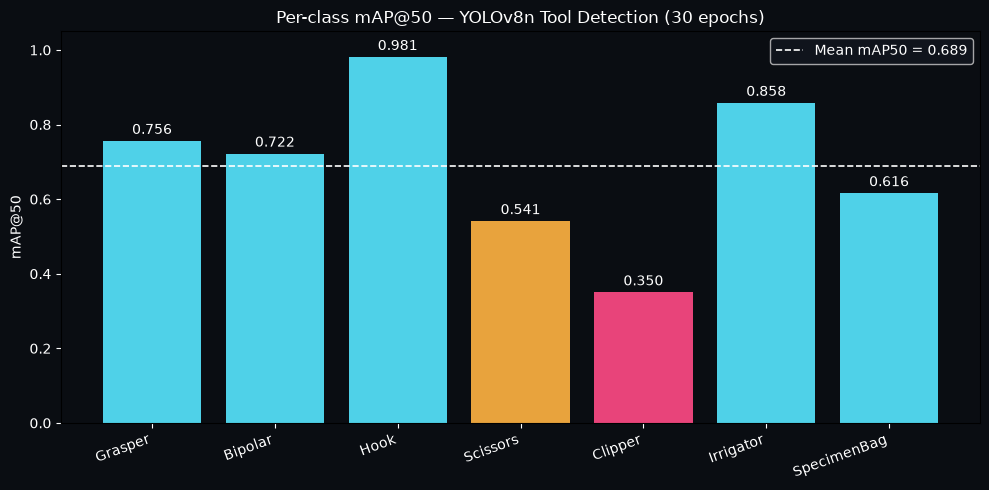


Exporting best.pt → ONNX ...
Ultralytics 8.4.75  Python-3.12.9 torch-2.12.1+cu126 CPU (Intel Core i7-9750H 2.60GHz)
Model summary (fused): 73 layers, 3,007,013 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from 'D:\Projects\oras\ml\runs\detect\tool_detection_v1\weights\best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 11, 8400) (5.9 MB)

ONNX: starting export with onnx 1.22.0 opset 20...
ONNX: slimming with onnxslim 0.1.94...
ONNX: export success  1.9s, saved as 'D:\Projects\oras\ml\runs\detect\tool_detection_v1\weights\best.onnx' (11.7 MB)

Export complete (3.1s)
Results saved to D:\Projects\oras\ml\runs\detect\tool_detection_v1\weights\best.onnx
Predict:         yolo predict task=detect model=D:\Projects\oras\ml\runs\detect\tool_detection_v1\weights\best.onnx imgsz=640 
Validate:        yolo val task=detect model=D:\Projects\oras\ml\runs\detect\tool_detection_v1\weights\best.onnx imgsz=640 data=D:\Projects\oras\ml\datasets\cholec80_boxes_yolo\data.yaml

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

ERROR TensorFlow SavedModel: export failure 365.4s: module 'numpy' has no attribute '_no_nep50_warning'


AttributeError: module 'numpy' has no attribute '_no_nep50_warning'

In [3]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path
from ultralytics import YOLO

RUNS_DIR  = Path(r"D:\Projects\oras\ml\runs\detect\tool_detection_v1")
BEST_PT   = RUNS_DIR / "weights" / "best.pt"
EXPORT_DIR = Path(r"D:\Projects\oras\ml\models")
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

# ── 1. Training curves ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))
ax.imshow(mpimg.imread(RUNS_DIR / "results.png"))
ax.axis("off")
ax.set_title("Training Curves — 30 Epochs", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# ── 2. Confusion matrix ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, fname, title in zip(
    axes,
    ["confusion_matrix_normalized.png", "confusion_matrix.png"],
    ["Normalized Confusion Matrix", "Raw Confusion Matrix"],
):
    ax.imshow(mpimg.imread(RUNS_DIR / fname))
    ax.axis("off")
    ax.set_title(title, fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

# ── 3. PR curve ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))
ax.imshow(mpimg.imread(RUNS_DIR / "BoxPR_curve.png"))
ax.axis("off")
ax.set_title("Precision-Recall Curve (per class)", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

# ── 4. Per-class mAP50 bar chart ──────────────────────────────────────────────
class_names  = ["Grasper", "Bipolar", "Hook", "Scissors", "Clipper", "Irrigator", "SpecimenBag"]
map50_scores = [0.756,      0.722,    0.981,  0.541,      0.350,     0.858,       0.616]
colors       = ["#4FD1E8" if s >= 0.6 else "#E8A33D" if s >= 0.45 else "#E8447A"
                for s in map50_scores]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(class_names, map50_scores, color=colors, edgecolor="none")
ax.axhline(0.689, color="white", linestyle="--", linewidth=1.2, label="Mean mAP50 = 0.689")
for bar, score in zip(bars, map50_scores):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{score:.3f}", ha="center", va="bottom", fontsize=10, color="white")
ax.set_ylim(0, 1.05)
ax.set_ylabel("mAP@50", color="white")
ax.set_title("Per-class mAP@50 — YOLOv8n Tool Detection (30 epochs)", color="white")
ax.tick_params(colors="white")
ax.legend(facecolor="#12161F", labelcolor="white")
ax.set_facecolor("#0A0D12")
fig.patch.set_facecolor("#0A0D12")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

# ── 5. Export to ONNX ─────────────────────────────────────────────────────────
print("\nExporting best.pt → ONNX ...")
model = YOLO(str(BEST_PT))
onnx_path = model.export(format="onnx", imgsz=640, simplify=True)
print(f"ONNX saved → {onnx_path}")

# Copy to models/ folder for clean access
import shutil
onnx_dest = EXPORT_DIR / "tool_detection.onnx"
shutil.copy(onnx_path, onnx_dest)
print(f"Copied → {onnx_dest}")

# ── 6. Export to TFLite ───────────────────────────────────────────────────────
print("\nExporting best.pt → TFLite INT8 ...")
tflite_path = model.export(format="tflite", imgsz=640, int8=True)
print(f"TFLite saved → {tflite_path}")

tflite_dest = EXPORT_DIR / "tool_detection.tflite"
shutil.copy(tflite_path, tflite_dest)
print(f"Copied → {tflite_dest}")

print("\n--- Module 4 Complete ---")
print(f"ONNX  : {onnx_dest}")
print(f"TFLite: {tflite_dest}")
print(f"best.pt mAP50 = 0.689 | Hook=0.981 | Grasper=0.756 | Clipper=0.350")